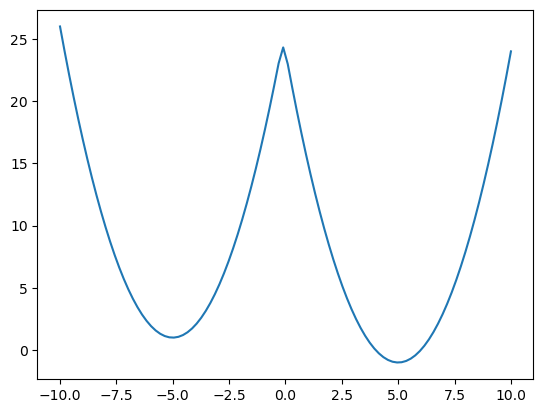

In [9]:
import numpy as np
import matplotlib.pyplot as plt

mu1    = -5
sigma1 = 1
mu2    = 5
sigma2 = 1

x = np.linspace(-10,10,100)

A = np.exp(-np.square(x-mu1))
B = np.exp(-np.square(x-mu2))

y = -np.log(A + B)

plt.plot(x,y)

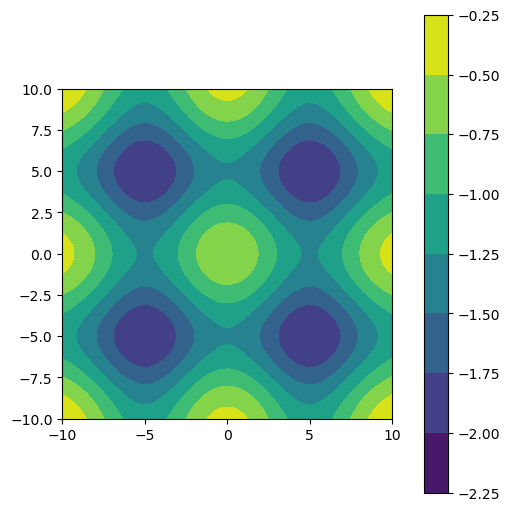

In [61]:

x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = (-5,-5)
p2 = (5,5)

E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r_x_1 = np.abs(x[i]-p1[0])
        r_x_2 = np.abs(x[i]-p2[0])

        r_y_1 = np.abs(y[j]-p1[1])
        r_y_2 = np.abs(y[j]-p1[1])

        Ex = -(np.exp(-np.square(x[i]-p2[0])/(2*sigma1**2)) + np.exp(-np.square(x[i]-p1[0])/(2*sigma2**2)))
        Ey = -(np.exp(-np.square(y[j]-p2[1])/(2*sigma1**2)) + np.exp(-np.square(y[j]-p1[1])/(2*sigma2**2)))

        E[i,j] = Ex + Ey

X,Y = np.meshgrid(np.linspace(-10,10,100),np.linspace(-10,10,100))
fig, axs = plt.subplots(1,1,figsize=(5,5),layout='constrained')
c = axs.contourf(X,Y,E)
axs.set_aspect('equal')
fig.colorbar(c)

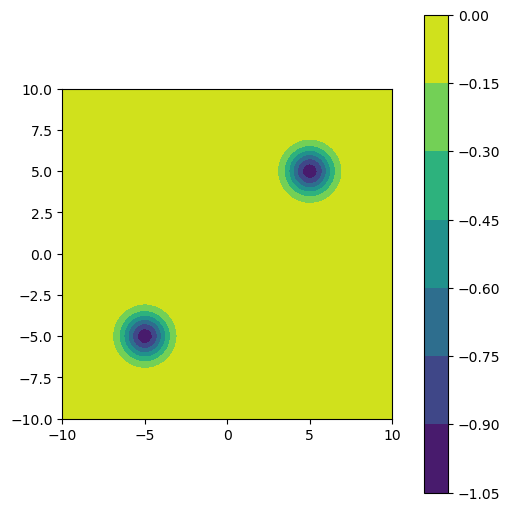

In [5]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = np.array([-5,-5])
p2 = np.array([5,5])

X,Y = np.meshgrid(np.linspace(-10,10,100),np.linspace(-10,10,100))
E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r1 = np.linalg.norm(np.array([x[i],y[j]])-p1)
        r2 = np.linalg.norm(np.array([x[i],y[j]])-p2)

        E[i,j] = -(np.exp(-np.square(r1)/(2*sigma1**2)) + np.exp(-np.square(r2)/(2*sigma2**2)))

fig, axs = plt.subplots(1,1,figsize=(5,5),layout='constrained')
c = axs.contourf(X,Y,E)
axs.set_aspect('equal')
fig.colorbar(c)

In [24]:
from openmmnapshift.utils import read_chemical_shifts

ATOM_TYPES = ['CA','CB','C','H','HA','N']

RC_CS_data = read_chemical_shifts("Data/1DJF/RC_CS.txt")
RC_CS = np.nan*np.ones((len(RC_CS_data.keys()),6))
for residx, residue_CS in enumerate(RC_CS_data.values()):
    for atom_idx, atom in enumerate(ATOM_TYPES):
        RC_CS[residx][atom_idx] = residue_CS[1][atom]

CS_data = read_chemical_shifts("Data/1DJF/CS.txt")
CS = np.nan*np.ones((len(CS_data.keys()),6))
for residx, residue_CS in enumerate(CS_data.values()):
    for atom_idx, atom in enumerate(ATOM_TYPES):
        CS[residx][atom_idx] = residue_CS[1][atom]

In [25]:
RC_CS

array([[ 55.826,  29.569, 176.044,   8.251,   4.352, 121.462],
       [ 51.324,  19.091, 176.53 ,   8.231,   4.394, 126.216],
       [ 62.508,  31.875, 176.851,     nan,   4.447, 137.18 ],
       [ 52.421,  19.257, 177.248,   8.284,   4.339, 124.462],
       [ 57.703,  38.776, 175.542,   8.3  ,   4.502, 120.426],
       [ 56.138,  32.796, 176.711,   8.315,   4.375, 123.768],
       [ 56.156,  32.942, 176.504,   8.295,   4.39 , 122.783],
       [ 52.697,  19.376, 177.535,   8.257,   4.345, 125.208],
       [ 52.558,  19.412, 177.594,   8.233,   4.319, 123.701],
       [ 56.197,  32.802, 176.69 ,   8.317,   4.369, 121.921],
       [ 56.071,  32.782, 176.54 ,   8.276,   4.388, 122.541],
       [ 55.01 ,  42.384, 177.17 ,   8.058,   4.365, 123.303],
       [ 52.697,  19.344, 177.951,   8.286,   4.35 , 125.457],
       [ 56.588,  30.361, 176.675,   8.385,   4.331, 120.56 ],
       [ 58.141,  63.723, 174.796,   8.263,   4.461, 116.681]])

In [50]:
CS.shape

(15, 6)

In [37]:
diff = (RC_CS-RC_CS)-(CS-RC_CS)
diff = np.where(np.isnan(diff),0,diff)
np.linalg.norm(diff)

13.31960310970263

In [56]:
np.nanmin(CS-RC_CS)

-0.7119999999999997

In [57]:
np.random.uniform(low=-1,high=5, size=CS.shape)

array([[ 1.33360872,  1.03260439,  2.23163349,  2.13122741,  0.92501105,
         2.97954896],
       [ 4.11374614,  4.20493866,  3.09785002,  2.73920622, -0.97547032,
         2.8629217 ],
       [ 2.66406626,  4.21292814,  3.08453078,  2.12339905,  2.47696532,
         0.10085803],
       [ 4.91080072,  1.19926336,  0.32016705,  1.03558199,  1.82468217,
         4.41705466],
       [ 0.33290366,  3.74436434, -0.88827146,  3.15384824,  0.94346164,
         3.24929393],
       [ 3.3725156 ,  1.51579236,  0.28398312,  2.55012595, -0.53399693,
         0.05305158],
       [ 0.30696492,  1.28271624,  2.90869268,  1.44648773,  2.19964291,
         2.94694297],
       [-0.80348863,  2.07895188,  0.68297421, -0.44020003,  4.20406302,
         1.1518697 ],
       [ 3.03043455,  3.49652023,  3.22788597,  0.37336658,  2.37249524,
         3.29821157],
       [ 4.23936827, -0.72548255, -0.49441471,  2.03637426,  1.41701293,
        -0.55143144],
       [ 2.55623188,  4.96523914,  1.54214063, -0.

In [64]:
p1

array([[ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., nan,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.]])

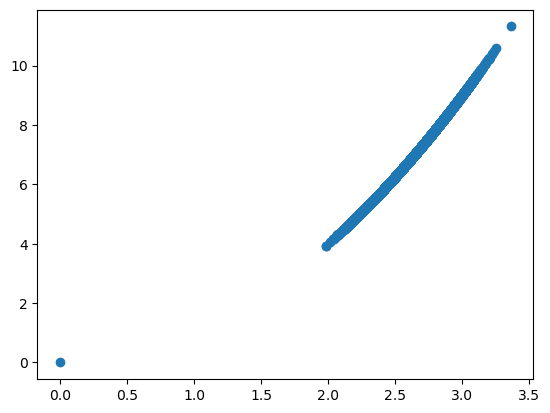

In [65]:
p1 = RC_CS-RC_CS
p2 = CS-RC_CS

r1s = [0]
ys = [0]

for i in range(100000):
    x = np.random.uniform(low=-1,high=5, size=CS.shape)
    r1 = np.sqrt(np.nanmean(np.square(x-p1)))
    r2 = np.sqrt(np.nanmean(np.square(x-p2)))

    A = np.exp(-np.square(r1))
    B = np.exp(-np.square(r2))
    y = -np.log(A + B)
    y = -np.log(A)

    r1s.append(r1)
    ys.append(y)

plt.scatter(r1s,ys)

In [ ]:


A = np.exp(-np.square(x-mu1))
B = np.exp(-np.square(x-mu2))

y = -np.log(A + B)


In [33]:
2*(30**2)

1800

In [35]:
(1000*1000*1000)/10

100000000.0

In [38]:
CS/2

array([[28.5  , 15.45 ,    nan,  4.02 ,  2.19 ,    nan],
       [26.7  ,  9.25 ,    nan,  4.085,  2.285,    nan],
       [32.9  , 16.3  ,    nan,    nan,  2.19 ,    nan],
       [27.95 ,  9.55 ,    nan,  4.005,  2.08 ,    nan],
       [30.55 , 19.4  ,    nan,  3.845,  2.185,    nan],
       [30.25 , 16.7  ,    nan,  3.895,  2.035,    nan],
       [30.25 , 16.75 ,    nan,  3.915,  2.03 ,    nan],
       [28.   ,  9.35 ,    nan,  3.985,  2.065,    nan],
       [28.1  ,  9.35 ,    nan,  4.075,  2.035,    nan],
       [30.15 , 16.9  ,    nan,  3.93 ,  2.045,    nan],
       [29.75 , 16.8  ,    nan,  3.945,  2.09 ,    nan],
       [29.5  , 21.4  ,    nan,  4.19 ,  2.07 ,    nan],
       [27.85 ,  9.6  ,    nan,  4.095,  2.1  ,    nan],
       [29.35 , 15.5  ,    nan,  4.05 ,  2.12 ,    nan],
       [30.3  , 32.6  ,    nan,  3.94 ,  2.23 ,    nan]])